In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [16]:
import numpy as np 
import pandas as pd

In [17]:
# housing = pd.read_csv("drive/MyDrive/pakistan_house_price_data.csv")
housing = pd.read_csv("pakistan_house_price_data.csv")

In [18]:
housing.head()

,Unnamed: 0,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,agency,agent,Total_Area
0,0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2/4/2019,NaN,NaN,1089.004
1,1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,5/4/2019,NaN,NaN,15246.056
2,2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,7/17/2019,NaN,NaN,2178.008
3,3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,4/5/2019,NaN,NaN,10890.000
4,4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,2178.008


In [19]:
housing = housing[housing['city'] == 'Islamabad']

In [20]:
housing = housing[housing['property_type'] == 'House']

In [21]:
housing["purpose"].value_counts()

For Sale    11908
For Rent     8004
Name: purpose, dtype: int64

In [22]:
housing = housing[housing['purpose'] == 'For Sale']

In [23]:
housing['price'] = housing['price'].apply(lambda x: x/100000)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


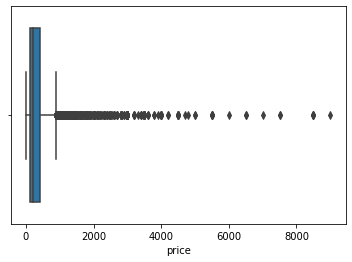

In [172]:
import seaborn as sns
sns.boxplot(housing['price'])

In [24]:
housing = housing[housing['price'] < 4000]

In [174]:
housing.shape

(11870, 18)

In [25]:
housing = housing.drop(housing.columns[[0]],axis = 1)

In [26]:
housing = housing.drop(['property_id', 'property_type', 'location_id', 'page_url', 'city', 'latitude', 'province_name', 'longitude', 'purpose', 'date_added', 'agency', 'agent'], axis=1)
housing.head()

,price,location,baths,bedrooms,Total_Area
2,165.0,G-15,6,5,2178.008
3,435.0,Bani Gala,4,4,10890.000
4,70.0,DHA Defence,3,3,2178.008
5,345.0,Ghauri Town,8,8,87120.000
6,270.0,Korang Town,8,8,5445.000


In [13]:
print(pd.unique(housing['location']))

['G-15' 'Bani Gala' 'DHA Defence' 'Ghauri Town' 'Korang Town' 'B-17'
 'G-11' 'Bhara kahu' 'Garden Town' 'Koral Town' 'Soan Garden' 'F-6' 'F-7'
 'I-16' 'E-7' 'Emaar Canyon Views' 'G-13' 'F-17' 'Bahria Town'
 'PWD Housing Scheme' 'F-11' 'Kuri Road' 'Pakistan Town'
 'Chatha Bakhtawar' 'E-11' 'F-10' 'F-8' 'I-8' 'Lehtarar Road' 'G-9' 'E-14'
 'G-8' 'I-14' 'Tarlai' 'Simly Dam Road' 'I-9' 'Burma Town'
 'National Police Foundation O-9' 'Naval Anchorage' 'Islamabad Highway'
 'CBR Town' 'National Police Foundation' 'G-10' 'Jhang Syedan' 'D-17'
 'Arsalan Town' 'Kashmir Highway' 'I-10' 'PWD Road' 'Pir Sohawa' 'Ali Pur'
 'FECHS' 'Khanna Pul' 'Shaheen Town' 'Jhangi Syedan' 'Chak Shahzad' 'H-13'
 'G-14' 'Shah Allah Ditta' 'Islamabad Expressway' 'Margalla Town' 'Tarnol'
 'H-15' 'D-13' 'Meherban Colony' 'Zaraj Housing Scheme'
 'Multi Residencia & Orchards' 'AGHOSH'
 'PAEC Employees Cooperative Housing Society' 'Taramrri' 'E-18'
 'Golra Mor' 'G-12' 'Shahpur' 'Spring Valley' 'Gulshan-e-Khudadad' 'D-12'
 '

In [15]:
housing.to_csv("isb_data.csv")

In [177]:
housing.shape

(11870, 5)

In [178]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11870 entries, 2 to 168312
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       11870 non-null  float64
 1   location    11870 non-null  object 
 2   baths       11870 non-null  int64  
 3   bedrooms    11870 non-null  int64  
 4   Total_Area  11870 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 556.4+ KB


In [179]:
housing["location"].value_counts()

DHA Defence        1420
G-13                942
Bahria Town         841
Ghauri Town         601
I-8                 506
                   ... 
Al Qaim Town          1
H-11                  1
PAF Tarnol            1
Capital Enclave       1
Bokra Road            1
Name: location, Length: 175, dtype: int64

In [180]:
housing.describe()

,price,baths,bedrooms,Total_Area
count,11870.000000,11870.000000,11870.000000,1.187000e+04
mean,353.800546,4.012890,4.222157,4.214460e+04
std,441.489680,2.676841,2.324489,3.109849e+06
min,0.000010,0.000000,0.000000,0.000000e+00
25%,120.000000,2.000000,3.000000,1.633506e+03
50%,200.000000,4.000000,4.000000,2.722510e+03
75%,425.000000,6.000000,6.000000,1.089000e+04
max,3900.000000,14.000000,16.000000,3.387988e+08


In [27]:
housing['location'] = housing['location'].apply(lambda x: x.strip())
location_count = housing['location'].value_counts()

In [28]:
location_count_less_10 = location_count[location_count <= 10]

In [29]:
housing['location'] = housing['location'].apply(lambda x: 'other' if x in location_count_less_10 else x)

In [30]:
housing['location'].value_counts()

DHA Defence                      1420
G-13                              942
Bahria Town                       841
Ghauri Town                       601
I-8                               506
                                 ... 
Shah Allah Ditta                   12
Koral Town                         11
Garden Town                        11
Islamabad - Murree Expressway      11
C-18                               11
Name: location, Length: 82, dtype: int64

In [185]:
housing

,price,location,baths,bedrooms,Total_Area
2,165.0,G-15,6,5,2178.008
3,435.0,Bani Gala,4,4,10890.000
4,70.0,DHA Defence,3,3,2178.008
5,345.0,Ghauri Town,8,8,87120.000
6,270.0,Korang Town,8,8,5445.000
...,...,...,...,...,...
168306,127.0,Soan Garden,3,3,2722.510
168307,270.0,G-13,4,4,1905.757
168308,90.0,Soan Garden,3,2,1633.506
168309,140.0,F-7,7,7,5445.000


In [31]:
X = housing.drop(columns=["price"])
y = housing["price"]

In [32]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler 

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [189]:
X_train.head()

,location,baths,bedrooms,Total_Area
160895,I-8,0,5,65340.000
101074,Bani Gala,5,5,2722.510
33136,Jhang Syedan,3,3,1361.255
80606,Zaraj Housing Scheme,5,4,3267.012
28103,B-17,7,5,2178.008


In [190]:
y_train.head()

160895    750.0
101074    105.0
33136      42.0
80606     190.0
28103     130.0
Name: price, dtype: float64

In [34]:
column_trans = make_column_transformer((OneHotEncoder(sparse=False), ['location']),
                                       remainder='passthrough')

In [35]:
scaler = StandardScaler()

In [193]:
lr = LinearRegression(normalize=True)

In [194]:
pipe = make_pipeline(column_trans, scaler, lr)

In [195]:
pipe.fit(X_train, y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_base.py:145: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), LinearRegression())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)


  FutureWarning,


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  ['location'])])),
                ('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression(normalize=True))])

In [196]:
y_pred_lr = pipe.predict(X_test)

In [197]:
r2_score(y_test, y_pred_lr)

0.6996517836827598

In [198]:
lasso = Lasso()

In [199]:
pipe = make_pipeline(column_trans, scaler, lasso)

In [200]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  ['location'])])),
                ('standardscaler', StandardScaler()), ('lasso', Lasso())])

In [201]:
y_pred_lasso = pipe.predict(X_test)

In [202]:
r2_score(y_test, y_pred_lasso)

0.6990893108617175

In [203]:
ridge = Ridge()

In [204]:
pipe = make_pipeline(column_trans, scaler, ridge)

In [205]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  ['location'])])),
                ('standardscaler', StandardScaler()), ('ridge', Ridge())])

In [206]:
y_pred_ridge = pipe.predict(X_test)

In [207]:
r2_score(y_test, y_pred_ridge)

0.6995102780244442

In [36]:
random_forest = RandomForestRegressor()

In [37]:
pipe_r = make_pipeline(column_trans, scaler, random_forest)

In [38]:
pipe_r.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  ['location'])])),
                ('standardscaler', StandardScaler()),
                ('randomforestregressor', RandomForestRegressor())])

In [39]:
y_pred_random = pipe_r.predict(X_test)

In [40]:
r2_score(y_test, y_pred_random)

0.8674067277908439

In [41]:
import pickle 

In [42]:
pickle.dump(pipe_r, open("isb_house_price_pred.pkl", "wb"))